In [12]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [13]:
mu = jnp.log(0.5)

t_vec = jnp.linspace(0,5,100)

def rhs(t,state,args):

    x,y = state
    mu = args
    #exponentiate to enforce positivity
    mu = jnp.exp(mu)

    # Nonlinear cubic term introduces limit cycle behavior.
    dx = mu * (x - 1/3 * x**3 - y)
    # Coupling term creates slow–fast dynamics when mu is large.
    dy = 1/mu * x


    return jnp.array([dx,dy])

In [14]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [15]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
# Initial condition: x(0)=3.0, y(0)=0.5
full_state = model(t_vec,jnp.array([3.,0.5]),(mu))

# Generate noisy observations of the first state component x(t) with additive Gaussian noise ~N(0,1).
noise_std = 1.0
observations = full_state[:,0] + noise_std * jax.random.normal(noise_key,shape = full_state[:,0].shape)



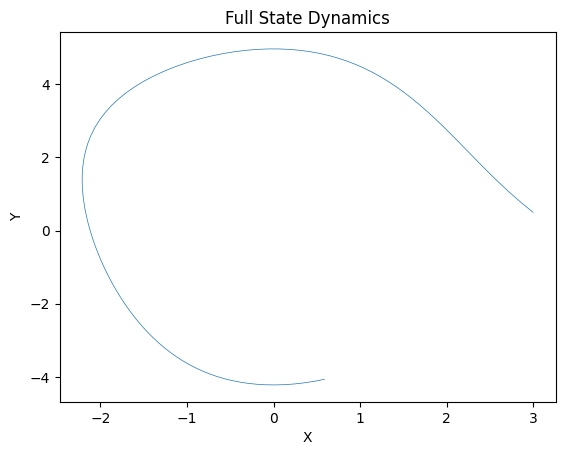

In [16]:
# Numerical solution of the ODE in x(t), y(t)
plt.plot(full_state[:,0],full_state[:,1],lw = 0.5)
plt.title('Full State Dynamics')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

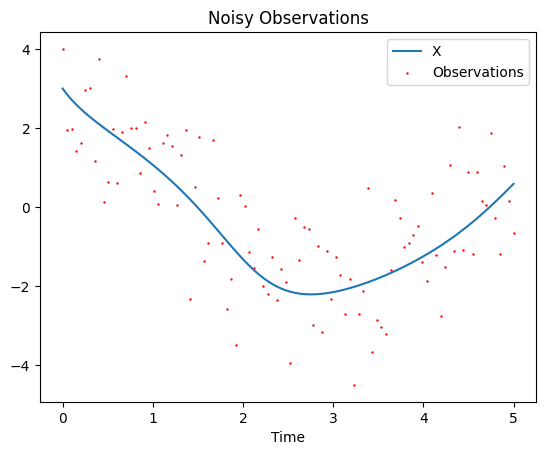

In [17]:
# Numerical solution of the ODE in t,x(t)
# We assume that the obervations are the red dots
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,0],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

In [18]:
'''Prior'''
tau = 5.0

@jax.jit
def log_prior(par,tau):
    mu = par
    return jax.scipy.stats.norm.logpdf(mu,scale = tau)

In [19]:
@jax.jit
def log_likelihood(par):
  mu = par
  model_output = model(t_vec,jnp.array([3.,0.5]),(mu))
  return jnp.sum(jax.scipy.stats.norm.logpdf(observations, model_output[:,0],scale = noise_std))

### Exercise A1 — Proposal Scale and Acceptance Rate

Modify the proposal standard deviation `proposal_std` in the random-walk Metropolis algorithm. Try values such as:
- 0.01
- 0.05
- 0.15
- 0.5
- 1.0

**Questions**

- What happens to the acceptance rate as `proposal_std` increases?
- Is a very high or very low acceptance rate desirable?


In [20]:
##MH
iterations = 1_000

proposal_stds = [0.01,0.05,0.15,0.5,1.0]

acceptance_rates = []

for std in proposal_stds:
    thetas = []
    LL = []

    theta_0 = 0.0
    thetas.append(theta_0)

    LL_0 = log_likelihood(theta_0) + log_prior(theta_0, tau)
    LL.append(LL_0)

    acceptances = []

    for iter in range(1, iterations):
        ##Proposal
        prop_key, rng_key = jax.random.split(rng_key)
        theta_prop = thetas[-1] + std * jax.random.normal(prop_key)

        LL_prop = log_likelihood(theta_prop) + log_prior(theta_prop, tau)
        alpha = LL_prop - LL[-1]

        rng_key, accept_key = jax.random.split(rng_key)
        if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
            LL.append(LL_prop)
            thetas.append(theta_prop)
            acceptances.append(1)

        else:
            LL.append(LL[-1])
            thetas.append(thetas[-1])
            acceptances.append(0)

        print(
            f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {jnp.exp(thetas[-1]):.4f}",
            end="\r",
        )

    acceptance_rates.append(sum(acceptances) / iter)

In [21]:
acceptance_rates

[0.993993993993994,
 0.94994994994995,
 0.8728728728728729,
 0.6276276276276276,
 0.44844844844844844]

The acceptance rate decreases as `proposal_std` increases. Too large of a proposal standard deviation leads to a low acceptance rate. A proposal standard deviation which is too small will yield a high acceptance rate but poor sampling, with a highly correlated chain. 

### Exercise A2 — Sensitivity to Initialization

Run the MCMC algorithm with different initial values:

- $ \theta_0 = 0 $
- $ \theta_0 = 5 $
- $ \theta_0 = -5 $

Keep all other settings fixed.


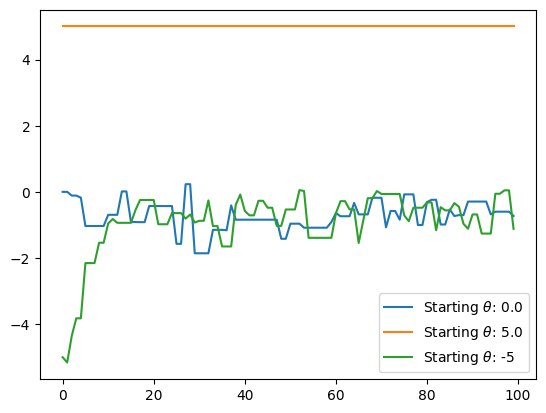

In [22]:
##MH
iterations = 100
theta0s = [0.,5.,-5]
proposal_std = 0.15

for theta_0 in theta0s:
    thetas = []
    LL = []
    acceptances = []

    sample_key, rng_key = jax.random.split(rng_key)

    thetas.append(theta_0)

    LL_0 = log_likelihood(theta_0) + log_prior(theta_0, tau)
    LL.append(LL_0)

    for iter in range(1, iterations):
        ##Proposal
        prop_key, rng_key = jax.random.split(rng_key)
        theta_prop = thetas[-1] + std * jax.random.normal(prop_key)

        LL_prop = log_likelihood(theta_prop) + log_prior(theta_prop, tau)
        alpha = LL_prop - LL[-1]

        rng_key, accept_key = jax.random.split(rng_key)
        if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
            LL.append(LL_prop)
            thetas.append(theta_prop)
            acceptances.append(1)

        else:
            LL.append(LL[-1])
            thetas.append(thetas[-1])
            acceptances.append(0)

        print(
            f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {jnp.exp(thetas[-1]):.4f}",
            end="\r",
        )

    plt.plot(thetas,label = f'Starting $\\theta$: {theta_0}')
plt.legend()
plt.show()

### Exercise A3 — Prior Sensitivity

Change the prior variance $( \tau^2 )$ in
$\theta \sim \mathcal{N}(0, \tau^2)$
to
- $ \tau = 0.1 $
- $ \tau = 1 $
- $ \tau = 20 $

**Questions**

- How does tightening or loosening the prior affect the posterior?

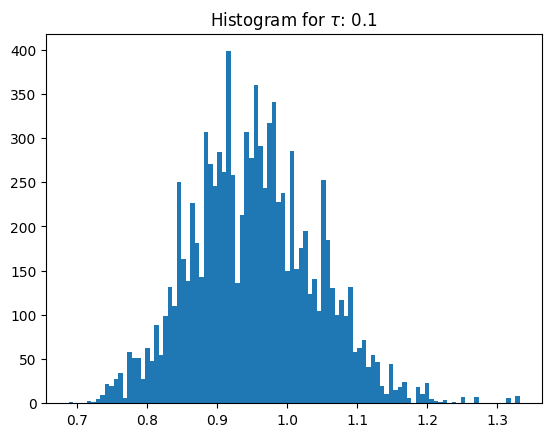

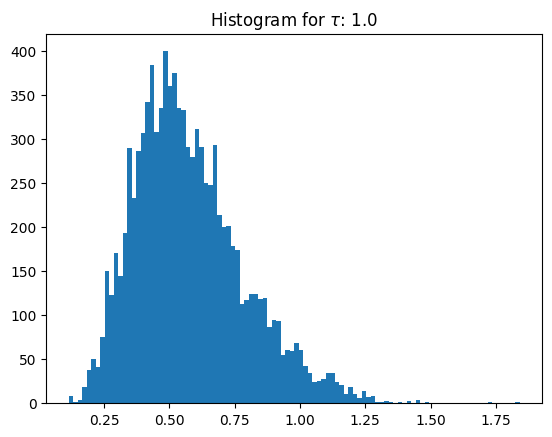

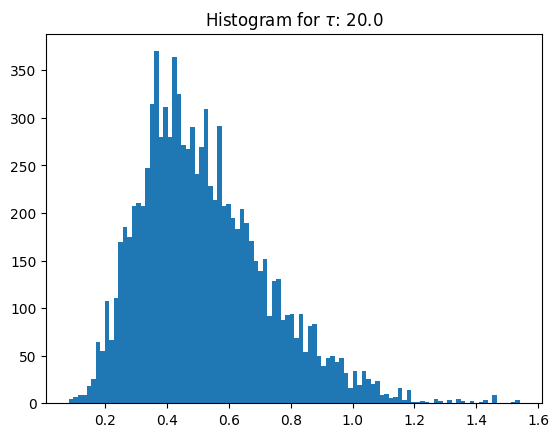

In [26]:
##MH
iterations = 10_000
taus = [0.1,1.,20.]
proposal_std = 0.15

for tau_val in taus:
    thetas = []
    LL = []
    acceptances = []

    sample_key, rng_key = jax.random.split(rng_key)

    theta_0 = 0.

    thetas.append(theta_0)

    LL_0 = log_likelihood(theta_0) + log_prior(theta_0, tau_val)
    LL.append(LL_0)

    for iter in range(1, iterations):
        ##Proposal
        prop_key, rng_key = jax.random.split(rng_key)
        theta_prop = thetas[-1] + std * jax.random.normal(prop_key)

        LL_prop = log_likelihood(theta_prop) + log_prior(theta_prop, tau_val)
        alpha = LL_prop - LL[-1]

        rng_key, accept_key = jax.random.split(rng_key)
        if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
            LL.append(LL_prop)
            thetas.append(theta_prop)
            acceptances.append(1)

        else:
            LL.append(LL[-1])
            thetas.append(thetas[-1])
            acceptances.append(0)

        print(
            f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {jnp.exp(thetas[-1]):.4f}",
            end="\r",
        )
    burn_in = 100
    plt.title(f"Histogram for $\\tau$: {tau_val}")
    plt.hist(jnp.exp(jnp.array(thetas[burn_in:])),bins = 100)
    plt.show()